# Error Analysis - 4 Models

Notebook nay tong hop va so sanh loi cua 4 mo hinh tren tap test: SVM, XLM-RoBERTa, PhoBERT va Qwen. Cac du doan duoc chuan hoa ve cung schema, sau do danh gia theo metric tong the, theo aspect, theo slice va theo tung case review.

## Noi dung chinh

1. Chuan hoa prediction va kiem tra schema
2. Phase 1 - Overall metrics
3. Phase 2 - Per-aspect comparison
4. Phase 3 - Slice analysis
5. Phase 4 - Error case deep-dive
6. Phase 5 - Model-level takeaway table
7. Acceptance checks


In [1]:
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
PRED_DIR = PROJECT_ROOT / "data" / "pred"
GOLD_TEST_PATH = PROJECT_ROOT / "data" / "gold" / "test.csv"
OUT_DIR = PRED_DIR / "standardized"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ASPECTS = [
    "graphics",
    "matchmaking",
    "store & microtransactions",
    "technical_issue",
    "mechanics",
    "developer_support",
    "event",
    "community",
    "hero_design",
    "difficulty",
]

MODEL_FILES = {
    "qwen": PRED_DIR / "test_pred_qWen.csv",
    "svm": PRED_DIR / "test_pred_SVM.csv",
    "xlm": PRED_DIR / "test_pred_XLM.csv",
    "phobert": PRED_DIR / "test_pred_PhoBERT.csv",
}

LABEL_COLS = [col for aspect in ASPECTS for col in (f"{aspect}_true", f"{aspect}_pred")]
STD_COLS = ["model", "review", *LABEL_COLS, "n_errors"]

In [2]:
def fix_mojibake(value):
    """Repair common UTF-8 text that was read as latin-1/cp1252."""
    if not isinstance(value, str):
        return value
    if not any(marker in value for marker in ("Ã", "Ä", "Æ", "áº", "á»")):
        return value
    for source_encoding in ("latin1", "cp1252"):
        try:
            return value.encode(source_encoding).decode("utf-8")
        except UnicodeError:
            pass
    return value


def read_csv_safely(path):
    """Read CSV with a few likely encodings, then repair mojibake in object columns."""
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "cp1258", "latin1"):
        try:
            df = pd.read_csv(path, encoding=encoding)
            break
        except UnicodeDecodeError as exc:
            last_error = exc
    else:
        raise last_error

    text_cols = df.select_dtypes(include="object").columns
    for col in text_cols:
        df[col] = df[col].map(fix_mojibake)
    return df


def parse_label_list(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    if pd.isna(value):
        raise ValueError("Missing label list")
    parsed = ast.literal_eval(value)
    if len(parsed) != len(ASPECTS):
        raise ValueError(f"Expected {len(ASPECTS)} labels, got {len(parsed)}: {value}")
    return [int(label) for label in parsed]


def add_error_count(df):
    true_cols = [f"{aspect}_true" for aspect in ASPECTS]
    pred_cols = [f"{aspect}_pred" for aspect in ASPECTS]
    df["n_errors"] = (df[true_cols].to_numpy() != df[pred_cols].to_numpy()).sum(axis=1)
    return df


def build_from_true_pred_columns(model, df):
    out = pd.DataFrame({"model": model, "review": df["review"]})
    for aspect in ASPECTS:
        out[f"{aspect}_true"] = df[f"{aspect}_true"].astype(int)
        out[f"{aspect}_pred"] = df[f"{aspect}_pred"].astype(int)
    return add_error_count(out)[STD_COLS]


def build_from_pred_columns(model, df, gold_df, pred_prefix="pred_"):
    if len(df) != len(gold_df):
        raise ValueError(f"{model}: prediction rows ({len(df)}) != gold rows ({len(gold_df)})")
    out = pd.DataFrame({"model": model, "review": gold_df["review"]})
    for aspect in ASPECTS:
        pred_col = f"{pred_prefix}{aspect}"
        out[f"{aspect}_true"] = gold_df[aspect].astype(int)
        out[f"{aspect}_pred"] = df[pred_col].astype(int)
    return add_error_count(out)[STD_COLS]


def build_from_aspect_columns(model, df, gold_df):
    if len(df) != len(gold_df):
        raise ValueError(f"{model}: prediction rows ({len(df)}) != gold rows ({len(gold_df)})")
    out = pd.DataFrame({"model": model, "review": gold_df["review"]})
    for aspect in ASPECTS:
        out[f"{aspect}_true"] = gold_df[aspect].astype(int)
        out[f"{aspect}_pred"] = df[aspect].astype(int)
    return add_error_count(out)[STD_COLS]


def build_from_label_lists(model, df):
    true_labels = df["true_labels"].map(parse_label_list)
    pred_labels = df["predicted_labels"].map(parse_label_list)
    out = pd.DataFrame({"model": model, "review": df["review"]})
    for idx, aspect in enumerate(ASPECTS):
        out[f"{aspect}_true"] = true_labels.map(lambda labels: labels[idx]).astype(int)
        out[f"{aspect}_pred"] = pred_labels.map(lambda labels: labels[idx]).astype(int)
    return add_error_count(out)[STD_COLS]


def standardize_predictions(model, path, gold_df):
    df = read_csv_safely(path)
    columns = set(df.columns)

    if all(f"{aspect}_true" in columns and f"{aspect}_pred" in columns for aspect in ASPECTS):
        standardized = build_from_true_pred_columns(model, df)
    elif {"true_labels", "predicted_labels"}.issubset(columns):
        standardized = build_from_label_lists(model, df)
    elif all(f"pred_{aspect}" in columns for aspect in ASPECTS):
        standardized = build_from_pred_columns(model, df, gold_df)
    elif all(aspect in columns for aspect in ASPECTS):
        standardized = build_from_aspect_columns(model, df, gold_df)
    else:
        raise ValueError(f"Unsupported prediction format for {model}: {list(df.columns)}")

    output_path = OUT_DIR / f"test_pred_{model}_standardized.csv"
    standardized.to_csv(output_path, index=False, encoding="utf-8-sig")
    return standardized, output_path

In [3]:
gold_test = read_csv_safely(GOLD_TEST_PATH)

standardized_frames = []
saved_files = {}
for model, path in MODEL_FILES.items():
    standardized, output_path = standardize_predictions(model, path, gold_test)
    standardized_frames.append(standardized)
    saved_files[model] = output_path

all_predictions = pd.concat(standardized_frames, ignore_index=True)
combined_path = OUT_DIR / "all_model_predictions_standardized.csv"
all_predictions.to_csv(combined_path, index=False, encoding="utf-8-sig")

summary = (
    all_predictions
    .groupby("model")
    .agg(n_reviews=("review", "size"), total_label_errors=("n_errors", "sum"), mean_errors_per_review=("n_errors", "mean"))
    .sort_values("total_label_errors")
)

print("Saved standardized files:")
for model, path in saved_files.items():
    print(f"- {model}: {path.relative_to(PROJECT_ROOT)}")
print(f"- combined: {combined_path.relative_to(PROJECT_ROOT)}")

summary

Saved standardized files:
- qwen: data\pred\standardized\test_pred_qwen_standardized.csv
- svm: data\pred\standardized\test_pred_svm_standardized.csv
- xlm: data\pred\standardized\test_pred_xlm_standardized.csv
- phobert: data\pred\standardized\test_pred_phobert_standardized.csv
- combined: data\pred\standardized\all_model_predictions_standardized.csv


,n_reviews,total_label_errors,mean_errors_per_review
model,,,
qwen,519,304,0.585742
xlm,519,316,0.608863
svm,519,350,0.674374
phobert,519,529,1.019268


In [4]:
# Quick schema check before starting detailed error analysis.
expected_cols = set(STD_COLS)
schema_check = pd.DataFrame(
    {
        "model": model,
        "n_rows": len(frame),
        "has_expected_columns": set(frame.columns) == expected_cols,
        "missing_columns": sorted(expected_cols - set(frame.columns)),
        "extra_columns": sorted(set(frame.columns) - expected_cols),
    }
    for model, frame in zip(MODEL_FILES, standardized_frames)
)
schema_check

,model,n_rows,has_expected_columns,missing_columns,extra_columns
0,qwen,519,True,[],[]
1,svm,519,True,[],[]
2,xlm,519,True,[],[]
3,phobert,519,True,[],[]


In [5]:
# Preview rows with at least one wrong aspect label.
all_predictions.loc[all_predictions["n_errors"] > 0].head(10)

,model,review,graphics_true,graphics_pred,matchmaking_true,matchmaking_pred,store & microtransactions_true,store & microtransactions_pred,technical_issue_true,technical_issue_pred,...,developer_support_pred,event_true,event_pred,community_true,community_pred,hero_design_true,hero_design_pred,difficulty_true,difficulty_pred,n_errors
9,qwen,"sự kiện bắn bị khó vô cùng, nhờ bạn giúp thì c...",0,0,2,2,0,0,0,0,...,0,1,0,0,0,0,0,2,2,2
11,qwen,tính năng ghép quá chán team bạn thì cục top m...,0,1,2,2,0,2,2,2,...,2,2,2,2,2,0,0,0,0,3
13,qwen,không có ý gì đâu mà gà nên cho một cái trận t...,0,0,2,2,0,0,0,0,...,2,0,0,2,2,0,0,0,0,2
18,qwen,game tệ hại tỉ lệ gặp hack cao vô cùng để game...,0,0,0,2,0,0,2,2,...,2,0,0,2,2,0,0,0,0,1
19,qwen,vui lòng sửa lại cơ chế trừ uy tín,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
22,qwen,"game quá nặng, tướng kế bên không đánh được to...",0,0,0,0,0,0,2,2,...,0,0,0,0,0,2,0,0,0,1
23,qwen,tệ hại của xã hội,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
24,qwen,vui vừa hhee nhưng không có quân huy,0,0,0,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,2
29,qwen,chơi tổ hợp mà cứ bị trừ điểm uy tín,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
30,qwen,bản cập nhật mới cách xếp trận cứ sao sao ý đá...,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,2


## Shared helpers for analysis

The next cells reuse the standardized `all_predictions` dataframe and compute metrics consistently across all phases.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_fscore_support


MODEL_ORDER = ["qwen", "svm", "xlm", "phobert"]
LABELS = [0, 1, 2]
LABEL_NAMES = {0: "not_mentioned", 1: "positive_or_neutral", 2: "negative"}
TRUE_COLS = [f"{aspect}_true" for aspect in ASPECTS]
PRED_COLS = [f"{aspect}_pred" for aspect in ASPECTS]

sns.set_theme(style="whitegrid", font_scale=0.95)
pd.set_option("display.max_colwidth", 160)


def model_frame(model):
    frame = all_predictions.loc[all_predictions["model"] == model].reset_index(drop=True).copy()
    frame.insert(0, "sample_id", np.arange(len(frame)))
    return frame


def y_true_pred(model):
    frame = model_frame(model)
    return frame[TRUE_COLS].to_numpy(), frame[PRED_COLS].to_numpy()


def flatten_labels(model):
    y_true, y_pred = y_true_pred(model)
    return y_true.ravel(), y_pred.ravel()


def per_aspect_metric(model, metric_func, **kwargs):
    frame = model_frame(model)
    scores = {}
    for aspect in ASPECTS:
        scores[aspect] = metric_func(
            frame[f"{aspect}_true"],
            frame[f"{aspect}_pred"],
            labels=LABELS,
            zero_division=0,
            **kwargs,
        )
    return pd.Series(scores, name=model)


def per_review_correctness():
    correctness = None
    for model in MODEL_ORDER:
        frame = model_frame(model)
        model_correct = (frame[PRED_COLS].to_numpy() == frame[TRUE_COLS].to_numpy()).all(axis=1)
        review_col = "review" if model == MODEL_ORDER[0] else f"{model}_review"
        part = pd.DataFrame({"sample_id": frame["sample_id"], review_col: frame["review"], f"{model}_correct": model_correct, f"{model}_errors": frame["n_errors"]})
        correctness = part if correctness is None else correctness.merge(part, on="sample_id", how="inner")
    return correctness


base_reviews = model_frame(MODEL_ORDER[0])[["sample_id", "review", *TRUE_COLS]].copy()
base_reviews["n_true_aspects"] = (base_reviews[TRUE_COLS].to_numpy() != 0).sum(axis=1)
base_reviews["aspect_count_slice"] = pd.cut(
    base_reviews["n_true_aspects"],
    bins=[-0.1, 0.5, 1.5, 2.5, 3.5, np.inf],
    labels=["0", "1", "2", "3", "4+"],
)
base_reviews["token_count"] = base_reviews["review"].fillna("").astype(str).str.split().str.len()
base_reviews["length_slice"] = pd.qcut(
    base_reviews["token_count"],
    q=3,
    labels=["short", "medium", "long"],
    duplicates="drop",
)

assert set(all_predictions["model"].unique()) == set(MODEL_ORDER)
assert all(len(model_frame(model)) == len(base_reviews) for model in MODEL_ORDER)

print(f"Ready: {len(base_reviews)} reviews, {len(ASPECTS)} aspects, {len(MODEL_ORDER)} models")

Ready: 519 reviews, 10 aspects, 4 models


## Phase 1 - Overall metrics

Macro-F1, precision, recall, and per-class F1 on the test set.

In [7]:
phase1_rows = []
for model in MODEL_ORDER:
    y_true_flat, y_pred_flat = flatten_labels(model)
    aspect_f1 = per_aspect_metric(model, f1_score, average="macro")
    phase1_rows.append(
        {
            "model": model,
            "macro_f1_avg_aspects": aspect_f1.mean(),
            "macro_f1_flat": f1_score(y_true_flat, y_pred_flat, labels=LABELS, average="macro", zero_division=0),
            "precision_macro_flat": precision_score(y_true_flat, y_pred_flat, labels=LABELS, average="macro", zero_division=0),
            "recall_macro_flat": recall_score(y_true_flat, y_pred_flat, labels=LABELS, average="macro", zero_division=0),
            "exact_match_rate": (model_frame(model)["n_errors"] == 0).mean(),
            "mean_errors_per_review": model_frame(model)["n_errors"].mean(),
        }
    )

phase1_summary = pd.DataFrame(phase1_rows).sort_values("macro_f1_avg_aspects", ascending=False)
display(phase1_summary.style.format({col: "{:.4f}" for col in phase1_summary.columns if col != "model"}))

,model,macro_f1_avg_aspects,macro_f1_flat,precision_macro_flat,recall_macro_flat,exact_match_rate,mean_errors_per_review
0,qwen,0.6375,0.7574,0.7687,0.7510,0.6012,0.5857
3,phobert,0.5581,0.6796,0.6402,0.7419,0.4605,1.0193
1,svm,0.5388,0.7221,0.7426,0.7043,0.5356,0.6744
2,xlm,0.5361,0.7422,0.7609,0.7273,0.5780,0.6089


class_name,negative,not_mentioned,positive_or_neutral
model,,,
qwen,0.8358,0.9687,0.4677
svm,0.7958,0.9643,0.4062
xlm,0.8236,0.9676,0.4355
phobert,0.7483,0.9425,0.3478


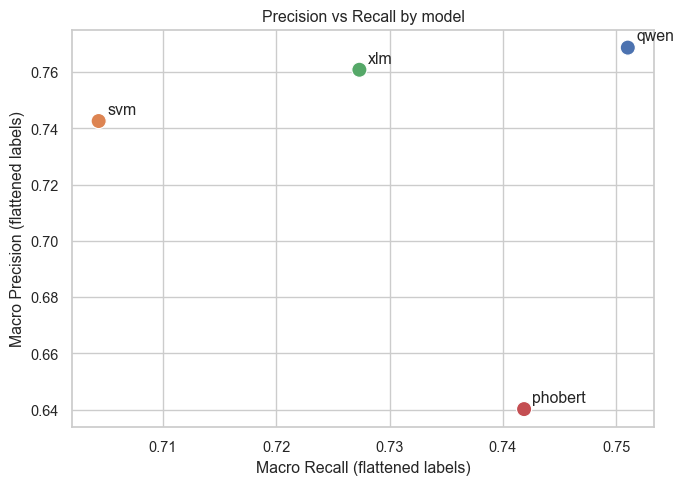

In [8]:
per_class_rows = []
for model in MODEL_ORDER:
    y_true_flat, y_pred_flat = flatten_labels(model)
    _, _, f1_per_class, support = precision_recall_fscore_support(
        y_true_flat,
        y_pred_flat,
        labels=LABELS,
        zero_division=0,
    )
    for label, f1_value, support_value in zip(LABELS, f1_per_class, support):
        per_class_rows.append(
            {
                "model": model,
                "class": label,
                "class_name": LABEL_NAMES[label],
                "f1": f1_value,
                "support": support_value,
            }
        )

per_class_f1 = pd.DataFrame(per_class_rows)
display(per_class_f1.pivot(index="model", columns="class_name", values="f1").loc[MODEL_ORDER].style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(7, 5))
plot_df = phase1_summary.set_index("model").loc[MODEL_ORDER].reset_index()
sns.scatterplot(data=plot_df, x="recall_macro_flat", y="precision_macro_flat", hue="model", s=120, ax=ax)
for _, row in plot_df.iterrows():
    ax.annotate(row["model"], (row["recall_macro_flat"], row["precision_macro_flat"]), xytext=(6, 5), textcoords="offset points")
ax.set_title("Precision vs Recall by model")
ax.set_xlabel("Macro Recall (flattened labels)")
ax.set_ylabel("Macro Precision (flattened labels)")
ax.legend().remove()
plt.tight_layout()
plt.show()

## Phase 2 - Per-aspect comparison

Per-aspect F1 heatmap, common/rare aspect views, and cross-error summaries for likely confusing pairs.

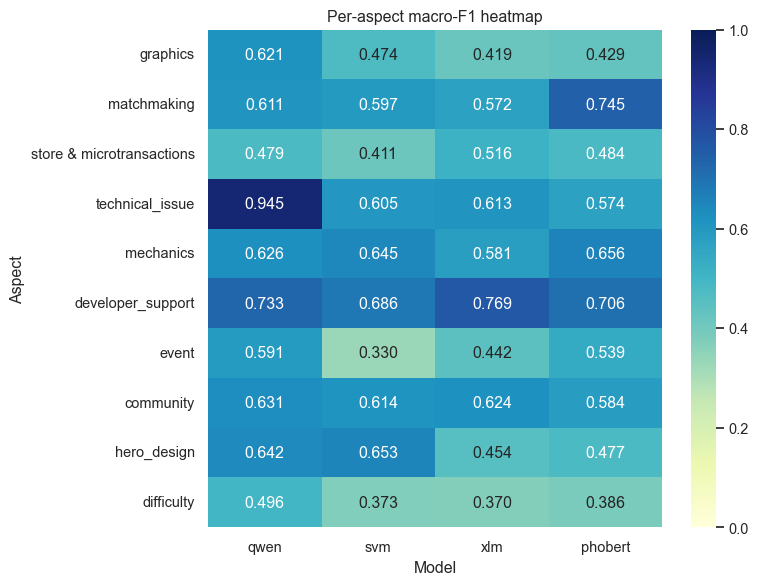

,qwen,svm,xlm,phobert
graphics,0.6210,0.4736,0.4193,0.4292
matchmaking,0.6106,0.5966,0.5723,0.7446
store & microtransactions,0.4787,0.4111,0.5155,0.4843
technical_issue,0.9446,0.6052,0.6131,0.5738
mechanics,0.6256,0.6446,0.5814,0.6564
developer_support,0.7332,0.6861,0.7693,0.7060
event,0.5910,0.3304,0.4422,0.5395
community,0.6314,0.6143,0.6242,0.5840
hero_design,0.6422,0.6532,0.4537,0.4769
difficulty,0.4964,0.3729,0.3701,0.3865


In [9]:
per_aspect_f1 = pd.DataFrame(
    {model: per_aspect_metric(model, f1_score, average="macro") for model in MODEL_ORDER}
).loc[ASPECTS, MODEL_ORDER]

assert per_aspect_f1.shape == (10, 4)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(per_aspect_f1, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("Per-aspect macro-F1 heatmap")
ax.set_xlabel("Model")
ax.set_ylabel("Aspect")
plt.tight_layout()
plt.show()

display(per_aspect_f1.style.format("{:.4f}"))

In [10]:
COMMON_ASPECTS = ["community", "technical_issue"]
RARE_ASPECTS = ["store & microtransactions", "event", "difficulty"]

common_aspect_table = per_aspect_f1.loc[COMMON_ASPECTS]
rare_aspect_table = per_aspect_f1.loc[RARE_ASPECTS]

print("Common aspects")
display(common_aspect_table.style.format("{:.4f}"))

print("Rare aspects")
display(rare_aspect_table.style.format("{:.4f}"))

Common aspects


,qwen,svm,xlm,phobert
community,0.6314,0.6143,0.6242,0.5840
technical_issue,0.9446,0.6052,0.6131,0.5738


Rare aspects


,qwen,svm,xlm,phobert
store & microtransactions,0.4787,0.4111,0.5155,0.4843
event,0.5910,0.3304,0.4422,0.5395
difficulty,0.4964,0.3729,0.3701,0.3865


In [11]:
CONFUSING_PAIRS = [("mechanics", "difficulty"), ("community", "matchmaking")]


def cross_error_summary(aspect_a, aspect_b):
    rows = []
    for model in MODEL_ORDER:
        frame = model_frame(model)
        true_a = frame[f"{aspect_a}_true"] != 0
        pred_a = frame[f"{aspect_a}_pred"] != 0
        true_b = frame[f"{aspect_b}_true"] != 0
        pred_b = frame[f"{aspect_b}_pred"] != 0
        rows.append(
            {
                "model": model,
                "pair": f"{aspect_a} <-> {aspect_b}",
                f"{aspect_a}_miss_when_{aspect_b}_pred": int(((true_a) & (~pred_a) & (pred_b)).sum()),
                f"{aspect_b}_miss_when_{aspect_a}_pred": int(((true_b) & (~pred_b) & (pred_a)).sum()),
                "both_true_one_or_both_wrong": int(((true_a & true_b) & ((pred_a != true_a) | (pred_b != true_b))).sum()),
                "pair_any_error": int(((pred_a != true_a) | (pred_b != true_b)).sum()),
            }
        )
    return pd.DataFrame(rows)


cross_error_tables = []
for aspect_a, aspect_b in CONFUSING_PAIRS:
    table = cross_error_summary(aspect_a, aspect_b)
    cross_error_tables.append(table)
    print(f"Cross-error summary: {aspect_a} <-> {aspect_b}")
    display(table)

cross_error_summary_all = pd.concat(cross_error_tables, ignore_index=True)

Cross-error summary: mechanics <-> difficulty


,model,pair,mechanics_miss_when_difficulty_pred,difficulty_miss_when_mechanics_pred,both_true_one_or_both_wrong,pair_any_error
0,qwen,mechanics <-> difficulty,0,4,2,65
1,svm,mechanics <-> difficulty,0,2,2,70
2,xlm,mechanics <-> difficulty,1,2,3,62
3,phobert,mechanics <-> difficulty,3,4,2,105


Cross-error summary: community <-> matchmaking


,model,pair,community_miss_when_matchmaking_pred,matchmaking_miss_when_community_pred,both_true_one_or_both_wrong,pair_any_error
0,qwen,community <-> matchmaking,7,6,14,57
1,svm,community <-> matchmaking,5,8,14,74
2,xlm,community <-> matchmaking,5,8,14,84
3,phobert,community <-> matchmaking,1,3,8,108


## Phase 3 - Slice analysis

Performance by number of true aspects, review length, and over-prediction behavior.

In [12]:
def slice_metrics(slice_col):
    rows = []
    for model in MODEL_ORDER:
        frame = model_frame(model).merge(base_reviews[["sample_id", slice_col]], on="sample_id", how="left")
        for slice_value, group in frame.groupby(slice_col, observed=False):
            if len(group) == 0:
                continue
            y_true = group[TRUE_COLS].to_numpy().ravel()
            y_pred = group[PRED_COLS].to_numpy().ravel()
            rows.append(
                {
                    "model": model,
                    "slice": str(slice_value),
                    "n_reviews": len(group),
                    "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
                    "precision_macro": precision_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
                    "recall_macro": recall_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
                    "mean_errors_per_review": group["n_errors"].mean(),
                }
            )
    return pd.DataFrame(rows)


aspect_count_slice_metrics = slice_metrics("aspect_count_slice")
length_slice_metrics = slice_metrics("length_slice")

expected_n = len(base_reviews)
aspect_slice_counts = aspect_count_slice_metrics.groupby("model")["n_reviews"].sum()
length_slice_counts = length_slice_metrics.groupby("model")["n_reviews"].sum()
assert (aspect_slice_counts == expected_n).all(), aspect_slice_counts
assert (length_slice_counts == expected_n).all(), length_slice_counts

print("Slice by number of true aspects")
display(aspect_count_slice_metrics.pivot(index="slice", columns="model", values="macro_f1")[MODEL_ORDER].style.format("{:.4f}"))

print("Slice by review length")
display(length_slice_metrics.pivot(index="slice", columns="model", values="macro_f1")[MODEL_ORDER].style.format("{:.4f}"))

Slice by number of true aspects


model,qwen,svm,xlm,phobert
slice,,,,
0,0.3310,0.3317,0.3317,0.6564
1,0.7280,0.7197,0.6808,0.7429
2,0.8181,0.6981,0.7580,0.6793
3,0.7336,0.7536,0.7649,0.5584
4+,0.5813,0.6746,0.5887,0.6715


Slice by review length


model,qwen,svm,xlm,phobert
slice,,,,
long,0.7329,0.7183,0.7360,0.6496
medium,0.7940,0.7399,0.7644,0.7229
short,0.7102,0.6688,0.6587,0.6783


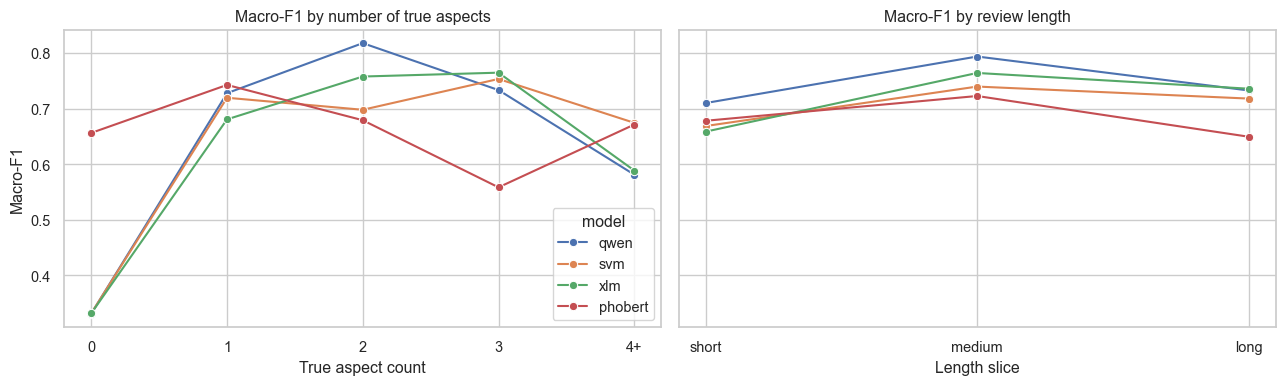

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
sns.lineplot(data=aspect_count_slice_metrics, x="slice", y="macro_f1", hue="model", marker="o", hue_order=MODEL_ORDER, ax=axes[0])
axes[0].set_title("Macro-F1 by number of true aspects")
axes[0].set_xlabel("True aspect count")
axes[0].set_ylabel("Macro-F1")

sns.lineplot(data=length_slice_metrics, x="slice", y="macro_f1", hue="model", marker="o", hue_order=MODEL_ORDER, ax=axes[1])
axes[1].set_title("Macro-F1 by review length")
axes[1].set_xlabel("Length slice")
axes[1].set_ylabel("Macro-F1")
axes[1].legend().remove()
plt.tight_layout()
plt.show()

,model,over_predict_rate_overall,over_predictions,true_absent_labels
3,phobert,0.0856,370,4321
0,qwen,0.0370,160,4322
2,xlm,0.0303,131,4322
1,svm,0.0273,118,4322


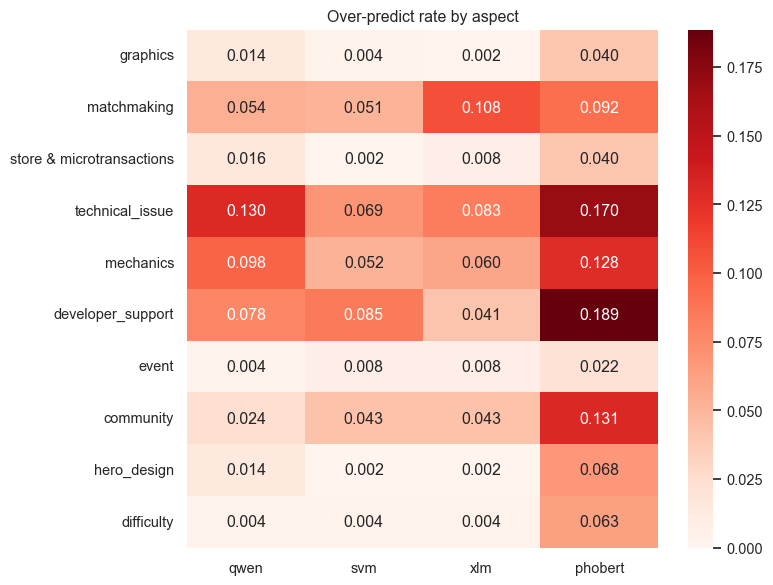

,qwen,svm,xlm,phobert
graphics,0.0139,0.0040,0.0020,0.0398
matchmaking,0.0539,0.0512,0.1078,0.0916
store & microtransactions,0.0161,0.0020,0.0080,0.0401
technical_issue,0.1300,0.0686,0.0830,0.1697
mechanics,0.0975,0.0525,0.0600,0.1275
developer_support,0.0775,0.0853,0.0413,0.1886
event,0.0039,0.0078,0.0078,0.0215
community,0.0244,0.0434,0.0434,0.1308
hero_design,0.0139,0.0020,0.0020,0.0677
difficulty,0.0040,0.0040,0.0040,0.0634


In [14]:
over_predict_rows = []
for model in MODEL_ORDER:
    frame = model_frame(model)
    true_matrix = frame[TRUE_COLS].to_numpy()
    pred_matrix = frame[PRED_COLS].to_numpy()
    over_mask = (true_matrix == 0) & (pred_matrix != 0)
    eligible_mask = true_matrix == 0
    over_predict_rows.append(
        {
            "model": model,
            "over_predict_rate_overall": over_mask.sum() / eligible_mask.sum(),
            "over_predictions": int(over_mask.sum()),
            "true_absent_labels": int(eligible_mask.sum()),
        }
    )

over_predict_summary = pd.DataFrame(over_predict_rows).sort_values("over_predict_rate_overall", ascending=False)
display(over_predict_summary.style.format({"over_predict_rate_overall": "{:.4f}"}))

over_predict_by_aspect = pd.DataFrame(index=ASPECTS, columns=MODEL_ORDER, dtype=float)
for model in MODEL_ORDER:
    frame = model_frame(model)
    for aspect in ASPECTS:
        absent = frame[f"{aspect}_true"] == 0
        over_predict_by_aspect.loc[aspect, model] = ((absent) & (frame[f"{aspect}_pred"] != 0)).sum() / max(absent.sum(), 1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(over_predict_by_aspect, annot=True, fmt=".3f", cmap="Reds", vmin=0, ax=ax)
ax.set_title("Over-predict rate by aspect")
plt.tight_layout()
plt.show()

display(over_predict_by_aspect.style.format("{:.4f}"))

## Phase 4 - Error case deep-dive

Detailed review-level audit tables: error taxonomy, case patterns, high-disagreement cases, and model-specific failures.


In [15]:
def label_dict_from_row(row, suffix):
    return {aspect: int(row[f"{aspect}_{suffix}"]) for aspect in ASPECTS}


def compact_nonzero_label_dict(label_dict):
    return {aspect: label for aspect, label in label_dict.items() if label != 0}


def aspect_error_type(true_label, pred_label):
    if true_label == pred_label:
        return "exact_correct"
    if true_label == 0 and pred_label != 0:
        return "false_positive_aspect"
    if true_label != 0 and pred_label == 0:
        return "false_negative_aspect"
    return "polarity_confusion"


def case_pattern_from_correctness(correct_models, wrong_models):
    if len(wrong_models) == 0:
        return "all_models_correct"
    if len(wrong_models) == len(MODEL_ORDER):
        return "all_models_wrong"
    if len(wrong_models) == 1:
        return f"only_{wrong_models[0]}_wrong"
    if len(correct_models) == 1:
        return f"only_{correct_models[0]}_correct"
    return f"{len(wrong_models)}_models_wrong"


def build_review_error_table():
    frames = {model: model_frame(model) for model in MODEL_ORDER}
    rows = []
    taxonomy_rows = []

    for sample_id in range(len(base_reviews)):
        base_row = base_reviews.iloc[sample_id]
        true_labels = {aspect: int(base_row[f"{aspect}_true"]) for aspect in ASPECTS}
        model_correct = {}
        model_error_counts = {}
        model_wrong_aspects = {}
        model_error_types = {}
        model_pred_labels = {}

        for model in MODEL_ORDER:
            model_row = frames[model].iloc[sample_id]
            pred_labels = {aspect: int(model_row[f"{aspect}_pred"]) for aspect in ASPECTS}
            model_pred_labels[model] = pred_labels

            wrong_aspects = []
            error_types = {}
            for aspect in ASPECTS:
                true_label = true_labels[aspect]
                pred_label = pred_labels[aspect]
                err_type = aspect_error_type(true_label, pred_label)
                taxonomy_rows.append(
                    {
                        "sample_id": sample_id,
                        "model": model,
                        "aspect": aspect,
                        "true": true_label,
                        "pred": pred_label,
                        "error_type": err_type,
                    }
                )
                if err_type != "exact_correct":
                    wrong_aspects.append(aspect)
                    error_types[aspect] = err_type

            model_wrong_aspects[model] = wrong_aspects
            model_error_types[model] = error_types
            model_error_counts[model] = len(wrong_aspects)
            model_correct[model] = len(wrong_aspects) == 0

        wrong_models = [model for model in MODEL_ORDER if not model_correct[model]]
        correct_models = [model for model in MODEL_ORDER if model_correct[model]]

        wrong_aspect_counts = {
            aspect: sum(aspect in model_wrong_aspects[model] for model in MODEL_ORDER)
            for aspect in ASPECTS
        }
        shared_wrong_aspects = [aspect for aspect, count in wrong_aspect_counts.items() if count >= 2]
        unanimous_wrong_aspects = [aspect for aspect, count in wrong_aspect_counts.items() if count == len(MODEL_ORDER)]
        pred_disagreement_aspects = [
            aspect
            for aspect in ASPECTS
            if len({model_pred_labels[model][aspect] for model in MODEL_ORDER}) > 1
        ]

        row = {
            "sample_id": sample_id,
            "review": base_row["review"],
            "n_true_aspects": int(base_row["n_true_aspects"]),
            "token_count": int(base_row["token_count"]),
            "aspect_count_slice": str(base_row["aspect_count_slice"]),
            "length_slice": str(base_row["length_slice"]),
            "true_labels_by_aspect": compact_nonzero_label_dict(true_labels),
            "case_pattern": case_pattern_from_correctness(correct_models, wrong_models),
            "correct_models": correct_models,
            "wrong_models": wrong_models,
            "model_wrong_count": len(wrong_models),
            "total_label_errors_across_models": int(sum(model_error_counts.values())),
            "shared_wrong_aspects": shared_wrong_aspects,
            "unanimous_wrong_aspects": unanimous_wrong_aspects,
            "pred_disagreement_aspects": pred_disagreement_aspects,
            "n_pred_disagreement_aspects": len(pred_disagreement_aspects),
        }

        for model in MODEL_ORDER:
            row[f"{model}_is_correct"] = model_correct[model]
            row[f"{model}_n_errors"] = model_error_counts[model]
            row[f"{model}_wrong_aspects"] = model_wrong_aspects[model]
            row[f"{model}_error_types"] = model_error_types[model]
            row[f"{model}_pred_by_aspect"] = compact_nonzero_label_dict(model_pred_labels[model])

        rows.append(row)

    return pd.DataFrame(rows), pd.DataFrame(taxonomy_rows)


review_error_table, error_taxonomy_long = build_review_error_table()
correctness = review_error_table[["sample_id", "review", *[f"{model}_is_correct" for model in MODEL_ORDER], *[f"{model}_n_errors" for model in MODEL_ORDER]]].rename(
    columns={**{f"{model}_is_correct": f"{model}_correct" for model in MODEL_ORDER}, **{f"{model}_n_errors": f"{model}_errors" for model in MODEL_ORDER}}
)
correct_cols = [f"{model}_correct" for model in MODEL_ORDER]
error_cols = [f"{model}_errors" for model in MODEL_ORDER]

valid_error_types = {"false_positive_aspect", "false_negative_aspect", "polarity_confusion", "exact_correct"}
assert set(error_taxonomy_long["error_type"].unique()).issubset(valid_error_types)
assert (review_error_table["model_wrong_count"] == len(MODEL_ORDER) - review_error_table[[f"{model}_is_correct" for model in MODEL_ORDER]].sum(axis=1)).all()

print(f"Deep-dive table ready: {len(review_error_table)} reviews x {len(review_error_table.columns)} columns")
print(f"Taxonomy table ready: {len(error_taxonomy_long)} model-aspect decisions")


Deep-dive table ready: 519 reviews x 36 columns
Taxonomy table ready: 20760 model-aspect decisions


In [16]:
case_pattern_summary = (
    review_error_table
    .groupby("case_pattern")
    .agg(
        n_reviews=("sample_id", "size"),
        mean_total_label_errors=("total_label_errors_across_models", "mean"),
        mean_pred_disagreement_aspects=("n_pred_disagreement_aspects", "mean"),
    )
    .sort_values("n_reviews", ascending=False)
)

model_wrong_count_summary = (
    review_error_table
    .groupby("model_wrong_count")
    .agg(n_reviews=("sample_id", "size"), mean_total_label_errors=("total_label_errors_across_models", "mean"))
)

error_type_summary = (
    error_taxonomy_long
    .groupby(["model", "error_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(MODEL_ORDER)
)

top_error_aspects = (
    error_taxonomy_long.loc[error_taxonomy_long["error_type"] != "exact_correct"]
    .groupby(["model", "aspect", "error_type"])
    .size()
    .reset_index(name="n_errors")
    .sort_values(["model", "n_errors"], ascending=[True, False])
)
top_error_aspects_by_model = top_error_aspects.groupby("model", group_keys=False).head(10)

print("Case pattern summary")
display(case_pattern_summary.style.format({"mean_total_label_errors": "{:.2f}", "mean_pred_disagreement_aspects": "{:.2f}"}))

print("Consensus/disagreement by number of wrong models")
display(model_wrong_count_summary.style.format({"mean_total_label_errors": "{:.2f}"}))

print("Error taxonomy by model")
display(error_type_summary)

print("Top error aspects by model")
display(top_error_aspects_by_model.reset_index(drop=True))


Case pattern summary


,n_reviews,mean_total_label_errors,mean_pred_disagreement_aspects
case_pattern,,,
only_phobert_wrong,184,2.60,2.60
all_models_wrong,149,8.06,3.74
2_models_wrong,79,3.67,3.19
all_models_correct,37,0.00,0.00
only_qwen_correct,30,5.50,3.60
only_svm_correct,17,5.71,4.06
only_xlm_correct,13,5.38,3.69
only_phobert_correct,4,4.50,1.75
only_svm_wrong,4,1.00,1.00


Consensus/disagreement by number of wrong models


,n_reviews,mean_total_label_errors
model_wrong_count,,
0,37,0.00
1,190,2.56
2,79,3.67
3,64,5.47
4,149,8.06


Error taxonomy by model


error_type,exact_correct,false_negative_aspect,false_positive_aspect,polarity_confusion
model,,,,
qwen,4886,109,160,35
svm,4840,193,118,39
xlm,4874,150,131,35
phobert,3833,533,792,32


Top error aspects by model


,model,aspect,error_type,n_errors
0,phobert,developer_support,false_positive_aspect,139
1,phobert,community,false_positive_aspect,134
2,phobert,technical_issue,false_positive_aspect,131
3,phobert,mechanics,false_positive_aspect,112
4,phobert,technical_issue,false_negative_aspect,110
5,phobert,matchmaking,false_positive_aspect,108
6,phobert,matchmaking,false_negative_aspect,97
7,phobert,community,false_negative_aspect,95
8,phobert,mechanics,false_negative_aspect,82
9,phobert,developer_support,false_negative_aspect,76


In [17]:
DETAILED_CASE_COLUMNS = [
    "sample_id",
    "review",
    "case_pattern",
    "n_true_aspects",
    "token_count",
    "aspect_count_slice",
    "length_slice",
    "true_labels_by_aspect",
    "wrong_models",
    "model_wrong_count",
    "total_label_errors_across_models",
    "shared_wrong_aspects",
    "unanimous_wrong_aspects",
    "pred_disagreement_aspects",
    "n_pred_disagreement_aspects",
]
for model in MODEL_ORDER:
    DETAILED_CASE_COLUMNS.extend([
        f"{model}_n_errors",
        f"{model}_wrong_aspects",
        f"{model}_error_types",
        f"{model}_pred_by_aspect",
    ])


def show_detailed_cases(title, frame, n=30):
    print(f"{title}: {len(frame)} cases. Showing {min(n, len(frame))} rows.")
    display(frame.head(n)[DETAILED_CASE_COLUMNS].reset_index(drop=True))


all_4_wrong_detailed = (
    review_error_table.loc[review_error_table["case_pattern"] == "all_models_wrong"]
    .sort_values(["total_label_errors_across_models", "n_pred_disagreement_aspects"], ascending=False)
)

single_model_wrong_detailed = {}
single_model_wrong_samples = {}
for model in MODEL_ORDER:
    cases = (
        review_error_table.loc[review_error_table["case_pattern"] == f"only_{model}_wrong"]
        .sort_values([f"{model}_n_errors", "n_pred_disagreement_aspects"], ascending=False)
    )
    single_model_wrong_detailed[model] = cases
    single_model_wrong_samples[model] = cases.head(min(30, len(cases)))

high_disagreement_cases = review_error_table.sort_values(
    ["n_pred_disagreement_aspects", "model_wrong_count", "total_label_errors_across_models"],
    ascending=False,
)

possible_label_review_cases = (
    review_error_table.loc[review_error_table["shared_wrong_aspects"].map(len) > 0]
    .sort_values(["model_wrong_count", "total_label_errors_across_models", "n_pred_disagreement_aspects"], ascending=False)
)

show_detailed_cases("All 4 models wrong detailed", all_4_wrong_detailed)
for model in MODEL_ORDER:
    show_detailed_cases(f"Only {model} wrong detailed", single_model_wrong_detailed[model])
show_detailed_cases("High-disagreement cases", high_disagreement_cases)
show_detailed_cases("Possible label-review cases", possible_label_review_cases)


All 4 models wrong detailed: 149 cases. Showing 30 rows.


,sample_id,review,case_pattern,n_true_aspects,token_count,aspect_count_slice,length_slice,true_labels_by_aspect,wrong_models,model_wrong_count,...,svm_error_types,svm_pred_by_aspect,xlm_n_errors,xlm_wrong_aspects,xlm_error_types,xlm_pred_by_aspect,phobert_n_errors,phobert_wrong_aspects,phobert_error_types,phobert_pred_by_aspect
0,87,"game càng ngày càng chán ghép như tệ hại, thêm cả đống skin cho tốn dung lượng, đề nghị xóa bớt skin không cần thiết, như skin nàng tiên gạo của yue",all_models_wrong,5,32,4+,long,"{'graphics': 2, 'matchmaking': 2, 'technical_issue': 2, 'developer_support': 2, 'hero_design': 1}","[qwen, svm, xlm, phobert]",4,...,"{'graphics': 'polarity_confusion', 'matchmaking': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_negative_...",{'graphics': 1},2,"[graphics, hero_design]","{'graphics': 'polarity_confusion', 'hero_design': 'false_negative_aspect'}","{'graphics': 1, 'matchmaking': 2, 'technical_issue': 2, 'developer_support': 2}",6,"[graphics, matchmaking, technical_issue, developer_support, community, hero_design]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_negati...",{'community': 2}
1,485,với một người ít bạn trong game như mình thì mình mong game sẽ bỏ nhiệm vụ chơi cùng bạn trong ssm nó rất tốn thời gian,all_models_wrong,3,27,3,long,"{'store & microtransactions': 1, 'developer_support': 1, 'event': 2}","[qwen, svm, xlm, phobert]",4,...,"{'store & microtransactions': 'false_negative_aspect', 'event': 'false_negative_aspect'}",{'developer_support': 1},2,"[store & microtransactions, event]","{'store & microtransactions': 'false_negative_aspect', 'event': 'false_negative_aspect'}",{'developer_support': 1},7,"[graphics, store & microtransactions, mechanics, developer_support, event, community, hero_design]","{'graphics': 'false_positive_aspect', 'store & microtransactions': 'polarity_confusion', 'mechanics': 'false_positive_aspect', 'developer_support': 'polarit...","{'graphics': 2, 'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2, 'hero_design': 2}"
2,125,không phải tự nhiên mà nhiều người đánh giá 1 sao. có bao giờ lấy điện thoại tầm trung ra chơi thử không. gặp tướng địch hay giao tranh tổng nhiều khi tướng...,all_models_wrong,3,48,3,long,"{'graphics': 1, 'technical_issue': 2, 'developer_support': 2}","[qwen, svm, xlm, phobert]",4,...,"{'graphics': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect'}",{'developer_support': 2},5,"[graphics, matchmaking, mechanics, developer_support, community]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_positive_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'false_negative_asp...","{'matchmaking': 2, 'technical_issue': 2, 'mechanics': 2, 'community': 2}",6,"[graphics, matchmaking, technical_issue, mechanics, developer_support, community]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_positive_aspect', 'technical_issue': 'false_negative_aspect', 'mechanics': 'false_positive_aspec...","{'matchmaking': 2, 'mechanics': 2, 'community': 2}"
3,231,game rất ok nhưng khi đánh rank có afk khi thua sẽ không bị trừ sao giống các mùa trước mong game thêm lại cơ chế không bị trừ sao khi gặp afk,all_models_wrong,4,33,4+,long,"{'matchmaking': 1, 'technical_issue': 2, 'mechanics': 1, 'community': 2}","[qwen, svm, xlm, phobert]",4,...,"{'matchmaking': 'polarity_confusion', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_positive_aspect'}","{'matchmaking': 2, 'mechanics': 1, 'developer_support': 1, 'community': 2}",4,"[matchmaking, technical_issue, mechanics, developer_support]","{'matchmaking': 'polarity_confusion', 'technical_issue': 'false_negative_aspect', 'mechanics': 'polarity_confusion', 'developer_support': 'false_positive_as...","{'matchmaking': 2, 'mechanics': 2, 'developer_support': 1, 'commun

Only qwen wrong detailed: 2 cases. Showing 2 rows.


,sample_id,review,case_pattern,n_true_aspects,token_count,aspect_count_slice,length_slice,true_labels_by_aspect,wrong_models,model_wrong_count,...,svm_error_types,svm_pred_by_aspect,xlm_n_errors,xlm_wrong_aspects,xlm_error_types,xlm_pred_by_aspect,phobert_n_errors,phobert_wrong_aspects,phobert_error_types,phobert_pred_by_aspect
0,121,"hết vụ yue rồi tới cny, thiệt luôn?",only_qwen_wrong,0,8,0,short,{},[qwen],1,...,{},{},0,[],{},{},0,[],{},{}
1,375,oắt luôn rõ ràng đúng mình không lại bảo sai không đăng nhập được,only_qwen_wrong,1,14,1,medium,{'technical_issue': 2},[qwen],1,...,{},{'technical_issue': 2},0,[],{},{'technical_issue': 2},0,[],{},{'technical_issue': 2}


Only svm wrong detailed: 4 cases. Showing 4 rows.


...

,sample_id,review,case_pattern,n_true_aspects,token_count,aspect_count_slice,length_slice,true_labels_by_aspect,wrong_models,model_wrong_count,...,svm_error_types,svm_pred_by_aspect,xlm_n_errors,xlm_wrong_aspects,xlm_error_types,xlm_pred_by_aspect,phobert_n_errors,phobert_wrong_aspects,phobert_error_types,phobert_pred_by_aspect
0,175,"không ổn lắm ý , cứ lag lag giật giật",only_phobert_wrong,1,10,1,medium,{'technical_issue': 2},[phobert],1,...,{},{'technical_issue': 2},0,[],{},{'technical_issue': 2},6,"[graphics, store & microtransactions, technical_issue, mechanics, developer_support, community]","{'graphics': 'false_positive_aspect', 'store & microtransactions': 'false_positive_aspect', 'technical_issue': 'false_negative_aspect', 'mechanics': 'false_...","{'graphics': 1, 'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}"
1,407,"bậc rank nào thì ghép đúng bậc rank đó, mắc cái gì cho bọn đại cao thủ cặp tinh anh vậy? toàn bọn tệ hại",only_phobert_wrong,2,25,2,long,"{'matchmaking': 2, 'community': 2}",[phobert],1,...,{},"{'matchmaking': 2, 'community': 2}",0,[],{},"{'matchmaking': 2, 'community': 2}",6,"[matchmaking, mechanics, developer_support, community, hero_design, difficulty]","{'matchmaking': 'false_negative_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'false_positive_aspect', 'community': 'false_negative_as...","{'mechanics': 2, 'developer_support': 2, 'hero_design': 2, 'difficulty': 2}"
2,1,tranh lane được mvp ra tố cáo không phát hiện vi phạm tôi quá thất vọng về game,only_phobert_wrong,4,18,4+,medium,"{'matchmaking': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}",[phobert],1,...,{},"{'matchmaking': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}",0,[],{},"{'matchmaking': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}",5,"[matchmaking, technical_issue, mechanics, developer_support, community]","{'matchmaking': 'false_negative_aspect', 'technical_issue': 'false_positive_aspect', 'mechanics': 'false_negative_aspect', 'developer_support': 'polarity_co...","{'technical_issue': 2, 'developer_support': 1}"
3,39,game ngày càng tệ,only_phobert_wrong,0,4,0,short,{},[phobert],1,...,{},{},0,[],{},{},5,"[graphics, technical_issue, mechanics, developer_support, hero_design]","{'graphics': 'false_positive_aspect', 'technical_issue': 'false_positive_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'false_positive...","{'graphics': 2, 'technical_issue': 2, 'mechanics': 2, 'developer_support': 2, 'hero_design': 2}"
4,59,game ghép như tệ hại ghép team toàn lũ tư duy thua thằng cấp 1 đại cao thủ 1 ghép cùng 4 5 sao mười mấy sao toàn rõ thế cũng nể nể nể,only_phobert_wrong,2,34,2,long,"{'matchmaking': 2, 'community': 2}",[phobert],1,...,{},"{'matchmaking': 2, 'community': 2}",0,[],{},"{'matchmaking': 2, 'community': 2}",5,"[matchmaking, mechanics, developer_support, community, hero_design]","{'matchmaking': 'false_negative_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'false_positive_aspect', 'community': 'false_negative_as...","{'mechanics': 2, 'developer_support': 1, 'hero_design': 1}"
5,257,game hay mà lag quá ạ.,only_phobert_wrong,1,6,1,short,{'technical_issue': 2},[phobert],1,...,{},{'technical_issue': 2},0,[],{},{'technical_issue': 2},5,"[store & microtransactions, technical_issue, mechanics, developer_support, community]","{'store & microtransactions': 'false_positive_aspect', 'technical_issue': 'false_negative_aspect', 'mechanics': 'false_positive_aspect', 'developer_support'...","{'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}"
6,283,"game ghép đội toàn tệ hại, thắng thì ít thua thì nhiều",only_phobert_wrong,2,12,2,medium,"{'matchmaking': 2, 'community': 2}",[phobert],1,...,{},"{'matchmaking': 2, 'community': 2}",0,[],{},"{'matchmaking': 2, 'community': 2}",5,"[matchmaking, technical_issue, developer_support, community, hero_design]","{'matchmaking': 'f

High-disagreement cases: 519 cases. Showing 30 rows.


,sample_id,review,case_pattern,n_true_aspects,token_count,aspect_count_slice,length_slice,true_labels_by_aspect,wrong_models,model_wrong_count,...,svm_error_types,svm_pred_by_aspect,xlm_n_errors,xlm_wrong_aspects,xlm_error_types,xlm_pred_by_aspect,phobert_n_errors,phobert_wrong_aspects,phobert_error_types,phobert_pred_by_aspect
0,32,"game hay nhưng chỉ cho 3 sao vì có nhiều phá game,hack,buff bẩn rồi afk tùm lum ... nhưng mong nhà phát hành sẽ cho chơi trên giả lập vì tôi không có điện t...",all_models_wrong,2,35,2,long,"{'developer_support': 1, 'community': 2}","[qwen, svm, xlm, phobert]",4,...,"{'technical_issue': 'false_positive_aspect', 'developer_support': 'polarity_confusion'}","{'technical_issue': 2, 'developer_support': 2, 'community': 2}",1,[technical_issue],{'technical_issue': 'false_positive_aspect'},"{'technical_issue': 2, 'developer_support': 1, 'community': 2}",7,"[graphics, store & microtransactions, mechanics, developer_support, event, community, hero_design]","{'graphics': 'false_positive_aspect', 'store & microtransactions': 'false_positive_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'pola...","{'graphics': 1, 'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'event': 2, 'hero_design': 2}"
1,261,"xử phạt afk phải bị trừ 4 sao thay cho những người còn lại. tự dưng bị trừ sao oan thay cho mấy thằng afk, nghĩ mà tệ hại",all_models_wrong,3,29,3,long,"{'matchmaking': 2, 'mechanics': 2, 'community': 2}","[qwen, svm, xlm, phobert]",4,...,{'developer_support': 'false_positive_aspect'},"{'matchmaking': 2, 'mechanics': 2, 'developer_support': 1, 'community': 2}",1,[developer_support],{'developer_support': 'false_positive_aspect'},"{'matchmaking': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2}",7,"[graphics, matchmaking, store & microtransactions, technical_issue, mechanics, event, community]","{'graphics': 'false_positive_aspect', 'matchmaking': 'false_negative_aspect', 'store & microtransactions': 'false_positive_aspect', 'technical_issue': 'fals...","{'graphics': 1, 'store & microtransactions': 1, 'technical_issue': 2, 'event': 1}"
2,406,game cứ cập nhật là phải tải tài nguyên lại trong khi đó đã tải hết rồi làm mất hứng chơi game,all_models_wrong,2,22,2,long,"{'technical_issue': 2, 'mechanics': 2}","[qwen, svm, xlm, phobert]",4,...,{'mechanics': 'false_negative_aspect'},{'technical_issue': 2},1,[mechanics],{'mechanics': 'false_negative_aspect'},{'technical_issue': 2},7,"[matchmaking, store & microtransactions, technical_issue, developer_support, event, hero_design, difficulty]","{'matchmaking': 'false_positive_aspect', 'store & microtransactions': 'false_positive_aspect', 'technical_issue': 'false_negative_aspect', 'developer_suppor...","{'matchmaking': 2, 'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'event': 2, 'hero_design': 2, 'difficulty': 2}"
3,213,chơi lên tinh anh cái gì reset hoài tụt xuống kim cương hoài rồi khi chơi rồi bị tố cáo tào lao tụt uy tín nữa chứ vai tệ hại,all_models_wrong,3,30,3,long,"{'matchmaking': 2, 'mechanics': 2, 'community': 2}","[qwen, svm, xlm, phobert]",4,...,{'community': 'false_negative_aspect'},"{'matchmaking': 2, 'mechanics': 2}",1,[community],{'community': 'false_negative_aspect'},"{'matchmaking': 2, 'mechanics': 2}",8,"[matchmaking, store & microtransactions, technical_issue, mechanics, developer_support, event, community, hero_design]","{'matchmaking': 'false_negative_aspect', 'store & microtransactions': 'false_positive_aspect', 'technical_issue': 'false_positive_aspect', 'mechanics': 'fal...","{'store & microtransactions': 2, 'technical_issue': 2, 'developer_support': 2, 'event': 1, 'hero_design': 1}"
4,85,"shop đá quý như tệ hại, skin cho rồi mà còn đòi lại",all_models_wrong,1,13,1,medium,{'store & microtransactions': 2},"[qwen, svm, xlm, phobert]",4,...,"{'graphics': 'false_positive_aspect', 'store & microtransactions': 'false_negative_aspect'}",{'graphics': 1},1,[graphics],{'graphics': 'fa

Possible label-review cases: 249 cases. Showing 30 rows.


,sample_id,review,case_pattern,n_true_aspects,token_count,aspect_count_slice,length_slice,true_labels_by_aspect,wrong_models,model_wrong_count,...,svm_error_types,svm_pred_by_aspect,xlm_n_errors,xlm_wrong_aspects,xlm_error_types,xlm_pred_by_aspect,phobert_n_errors,phobert_wrong_aspects,phobert_error_types,phobert_pred_by_aspect
0,87,"game càng ngày càng chán ghép như tệ hại, thêm cả đống skin cho tốn dung lượng, đề nghị xóa bớt skin không cần thiết, như skin nàng tiên gạo của yue",all_models_wrong,5,32,4+,long,"{'graphics': 2, 'matchmaking': 2, 'technical_issue': 2, 'developer_support': 2, 'hero_design': 1}","[qwen, svm, xlm, phobert]",4,...,"{'graphics': 'polarity_confusion', 'matchmaking': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_negative_...",{'graphics': 1},2,"[graphics, hero_design]","{'graphics': 'polarity_confusion', 'hero_design': 'false_negative_aspect'}","{'graphics': 1, 'matchmaking': 2, 'technical_issue': 2, 'developer_support': 2}",6,"[graphics, matchmaking, technical_issue, developer_support, community, hero_design]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_negati...",{'community': 2}
1,485,với một người ít bạn trong game như mình thì mình mong game sẽ bỏ nhiệm vụ chơi cùng bạn trong ssm nó rất tốn thời gian,all_models_wrong,3,27,3,long,"{'store & microtransactions': 1, 'developer_support': 1, 'event': 2}","[qwen, svm, xlm, phobert]",4,...,"{'store & microtransactions': 'false_negative_aspect', 'event': 'false_negative_aspect'}",{'developer_support': 1},2,"[store & microtransactions, event]","{'store & microtransactions': 'false_negative_aspect', 'event': 'false_negative_aspect'}",{'developer_support': 1},7,"[graphics, store & microtransactions, mechanics, developer_support, event, community, hero_design]","{'graphics': 'false_positive_aspect', 'store & microtransactions': 'polarity_confusion', 'mechanics': 'false_positive_aspect', 'developer_support': 'polarit...","{'graphics': 2, 'store & microtransactions': 2, 'mechanics': 2, 'developer_support': 2, 'community': 2, 'hero_design': 2}"
2,125,không phải tự nhiên mà nhiều người đánh giá 1 sao. có bao giờ lấy điện thoại tầm trung ra chơi thử không. gặp tướng địch hay giao tranh tổng nhiều khi tướng...,all_models_wrong,3,48,3,long,"{'graphics': 1, 'technical_issue': 2, 'developer_support': 2}","[qwen, svm, xlm, phobert]",4,...,"{'graphics': 'false_negative_aspect', 'technical_issue': 'false_negative_aspect'}",{'developer_support': 2},5,"[graphics, matchmaking, mechanics, developer_support, community]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_positive_aspect', 'mechanics': 'false_positive_aspect', 'developer_support': 'false_negative_asp...","{'matchmaking': 2, 'technical_issue': 2, 'mechanics': 2, 'community': 2}",6,"[graphics, matchmaking, technical_issue, mechanics, developer_support, community]","{'graphics': 'false_negative_aspect', 'matchmaking': 'false_positive_aspect', 'technical_issue': 'false_negative_aspect', 'mechanics': 'false_positive_aspec...","{'matchmaking': 2, 'mechanics': 2, 'community': 2}"
3,231,game rất ok nhưng khi đánh rank có afk khi thua sẽ không bị trừ sao giống các mùa trước mong game thêm lại cơ chế không bị trừ sao khi gặp afk,all_models_wrong,4,33,4+,long,"{'matchmaking': 1, 'technical_issue': 2, 'mechanics': 1, 'community': 2}","[qwen, svm, xlm, phobert]",4,...,"{'matchmaking': 'polarity_confusion', 'technical_issue': 'false_negative_aspect', 'developer_support': 'false_positive_aspect'}","{'matchmaking': 2, 'mechanics': 1, 'developer_support': 1, 'community': 2}",4,"[matchmaking, technical_issue, mechanics, developer_support]","{'matchmaking': 'polarity_confusion', 'technical_issue': 'false_negative_aspect', 'mechanics': 'polarity_confusion', 'developer_support': 'false_positive_as...","{'matchmaking': 2, 'mechanics': 2, 'developer_support': 1, 'commun

In [18]:
PHASE4_OUTPUT_DIR = OUT_DIR / "analysis_outputs"
PHASE4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def make_csv_safe(frame):
    csv_frame = frame.copy()
    for col in csv_frame.columns:
        if csv_frame[col].map(lambda value: isinstance(value, (dict, list))).any():
            csv_frame[col] = csv_frame[col].map(
                lambda value: json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else value
            )
    return csv_frame


phase4_export_tables = {
    "phase4_review_error_table": review_error_table,
    "phase4_error_taxonomy_long": error_taxonomy_long,
    "phase4_case_pattern_summary": case_pattern_summary,
    "phase4_model_wrong_count_summary": model_wrong_count_summary,
    "phase4_error_type_summary": error_type_summary.reset_index(),
    "phase4_top_error_aspects_by_model": top_error_aspects_by_model,
    "phase4_all_4_wrong_detailed": all_4_wrong_detailed[DETAILED_CASE_COLUMNS],
    "phase4_high_disagreement_cases": high_disagreement_cases[DETAILED_CASE_COLUMNS],
    "phase4_possible_label_review_cases": possible_label_review_cases[DETAILED_CASE_COLUMNS],
    "phase4_all_4_wrong_detailed_sample": all_4_wrong_detailed.head(30)[DETAILED_CASE_COLUMNS],
    "phase4_high_disagreement_cases_sample": high_disagreement_cases.head(30)[DETAILED_CASE_COLUMNS],
    "phase4_possible_label_review_cases_sample": possible_label_review_cases.head(30)[DETAILED_CASE_COLUMNS],
}

for model in MODEL_ORDER:
    phase4_export_tables[f"phase4_only_{model}_wrong_detailed"] = single_model_wrong_detailed[model][DETAILED_CASE_COLUMNS]
    phase4_export_tables[f"phase4_only_{model}_wrong_detailed_sample"] = single_model_wrong_detailed[model].head(30)[DETAILED_CASE_COLUMNS]

exported_phase4_files = []
for name, frame in phase4_export_tables.items():
    output_path = PHASE4_OUTPUT_DIR / f"{name}.csv"
    csv_frame = make_csv_safe(frame)
    csv_frame.to_csv(output_path, index=False, encoding="utf-8-sig")
    exported_phase4_files.append({
        "table": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "path": str(output_path),
    })

exported_phase4_files = pd.DataFrame(exported_phase4_files)
print(f"Exported {len(exported_phase4_files)} Phase 4 CSV files to {PHASE4_OUTPUT_DIR}")
display(exported_phase4_files)


Exported 20 Phase 4 CSV files to d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs


,table,rows,columns,path
0,phase4_review_error_table,519,36,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_review_error_table.csv
1,phase4_error_taxonomy_long,20760,6,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_error_taxonomy_long.csv
2,phase4_case_pattern_summary,10,3,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_case_pattern_summary.csv
3,phase4_model_wrong_count_summary,5,2,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_model_wrong_count_summary.csv
4,phase4_error_type_summary,4,5,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_error_type_summary.csv
5,phase4_top_error_aspects_by_model,40,4,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_top_error_aspects_by_model.csv
6,phase4_all_4_wrong_detailed,149,31,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_all_4_wrong_detailed.csv
7,phase4_high_disagreement_cases,519,31,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_high_disagreement_cases.csv
8,phase4_possible_label_review_cases,249,31,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_possible_label_review_cases.csv
9,phase4_all_4_wrong_detailed_sample,30,31,d:\Chuyên ngành\IE403\sentiment-analysis-game-domain\data\pred\standardized\analysis_outputs\phase4_all_4_wrong_detailed_sample.csv


### Nhan xet Phase 4

Phase 4 sau khi mo rong khong chi tra loi cau nao sai, ma con cho biet sai theo kieu nao. Bang `error_type_summary` tach loi thanh `false_positive_aspect`, `false_negative_aspect` va `polarity_confusion`, giup phan biet model dang doan du aspect, bo sot aspect hay nham polarity. Day la cach doc huu ich hon cho bao cao khoa hoc vi no noi duoc ban chat loi, khong chi dem so cau sai.

Nhom `all_models_wrong` la nhom can doc thu cong truoc tien. Neu nhieu model cung sai tren cung aspect (`shared_wrong_aspects` hoac `unanimous_wrong_aspects`), kha nang cao cau do mo ho, chua nhieu aspect, hoac guideline gan nhan chua ro. Bang `possible_label_review_cases` duoc tao rieng de gom cac cau nhu vay, phu hop de dua vao phan thao luan ve chat luong annotation.

Cac bang `only_<model>_wrong_detailed` giup nhin loi rieng cua tung model. Neu Qwen sai rieng, thuong nen doc xem prompt/generation co bo sot aspect hay nham polarity trong cau dai. Neu SVM sai rieng, nguyen nhan hop ly la TF-IDF n-gram khong nam duoc ngu canh. Neu XLM-R sai rieng, day co the la case kho ve multilingual/context. Neu PhoBERT sai rieng, nen doi chieu voi `false_positive_aspect` vi PhoBERT fine-tune voi class weight balanced va co dau hieu overfit, nen de over-predict aspect.

Bang `high_disagreement_cases` cho thay nhung cau ma cac model bat dong nhieu nhat. Day la nhom tot de trich dan trong bao cao: neu 4 model du doan khac nhau tren nhieu aspect, cau do dai dien cho vung bat dinh cua bai toan ABSA trong review game.


## Phase 5 - Model-level takeaway table

This table is generated from the previous metrics so it stays aligned with the actual results.

In [19]:
def top_items(series, n=2, ascending=False):
    ranked = series.sort_values(ascending=ascending)
    return ", ".join(ranked.head(n).index.tolist())


takeaway_rows = []
aspect_count_pivot = aspect_count_slice_metrics.pivot(index="model", columns="slice", values="macro_f1")
length_pivot = length_slice_metrics.pivot(index="model", columns="slice", values="macro_f1")

for model in MODEL_ORDER:
    model_aspect_scores = per_aspect_f1[model]
    strongest = top_items(model_aspect_scores, n=2, ascending=False)
    weakest = top_items(model_aspect_scores, n=2, ascending=True)
    best_aspect_count_slice = aspect_count_pivot.loc[model].idxmax()
    best_length_slice = length_pivot.loc[model].idxmax()
    over_rate = over_predict_summary.set_index("model").loc[model, "over_predict_rate_overall"]
    exact_match = phase1_summary.set_index("model").loc[model, "exact_match_rate"]
    takeaway_rows.append(
        {
            "model": model,
            "strengths": f"Highest aspect F1 on: {strongest}. Exact-match rate: {exact_match:.3f}.",
            "weaknesses": f"Lowest aspect F1 on: {weakest}. Over-predict rate: {over_rate:.3f}.",
            "best_when": f"Best slice: {best_aspect_count_slice} true aspect(s), {best_length_slice} reviews.",
        }
    )

final_takeaway_table = pd.DataFrame(takeaway_rows)
display(final_takeaway_table)

,model,strengths,weaknesses,best_when
0,qwen,"Highest aspect F1 on: technical_issue, developer_support. Exact-match rate: 0.601.","Lowest aspect F1 on: store & microtransactions, difficulty. Over-predict rate: 0.037.","Best slice: 2 true aspect(s), medium reviews."
1,svm,"Highest aspect F1 on: developer_support, hero_design. Exact-match rate: 0.536.","Lowest aspect F1 on: event, difficulty. Over-predict rate: 0.027.","Best slice: 3 true aspect(s), medium reviews."
2,xlm,"Highest aspect F1 on: developer_support, community. Exact-match rate: 0.578.","Lowest aspect F1 on: difficulty, graphics. Over-predict rate: 0.030.","Best slice: 3 true aspect(s), medium reviews."
3,phobert,"Highest aspect F1 on: matchmaking, developer_support. Exact-match rate: 0.461.","Lowest aspect F1 on: difficulty, graphics. Over-predict rate: 0.086.","Best slice: 1 true aspect(s), medium reviews."


### Nhan xet Phase 5

Bang tong ket cho thay **Qwen** la lua chon tot nhat neu uu tien hieu nang tong the va kha nang hieu ngu canh. Diem manh lon nhat la technical_issue, developer_support va hero_design; diem yeu con lai nam o cac aspect hiem nhu store & microtransactions va difficulty.

**SVM** phu hop lam baseline manh, nhe va de giai thich. Viec dung TF-IDF n-gram `(1,3)` giup mo hinh bat duoc cum tu dac trung trong review game, con `class_weight="balanced"` va `C=0.5` giup kiem soat mat can bang/overfit. Tuy nhien, do khong hieu ngu nghia sau, SVM yeu o event, difficulty va store.

**XLM-R** la mo hinh can bang, it loi rieng va hoat dong tot o developer_support/community. Tuy nhien, vi fine-tune voi `MAX_LEN=128`, 10 epoch va classifier chung cho 10 aspect, mo hinh chua but pha o aspect kho hoac hiem. XLM-R phu hop lam mo hinh so sanh Transformer on dinh.

**PhoBERT** co tiem nang o matchmaking, developer_support va mechanics, nhung ban fine-tune hien tai bi over-predict ro. Du dung PhoBERT-base phu hop tieng Viet va co nhieu head theo aspect, class weight balanced cung voi dau hieu overfit khien precision thap va exact-match kem. PhoBERT nen duoc cai thien bang early stopping chat hon, threshold/calibration hoac dieu chinh loss truoc khi dung lam model chinh.


## Acceptance checks

These checks guard the expected shape of the analysis outputs.

In [20]:
assert len(phase1_summary) == len(MODEL_ORDER)
assert set(phase1_summary["model"]) == set(MODEL_ORDER)
assert per_aspect_f1.shape == (len(ASPECTS), len(MODEL_ORDER))
assert not aspect_count_slice_metrics.empty
assert not length_slice_metrics.empty
assert not over_predict_summary.empty
assert len(final_takeaway_table) == len(MODEL_ORDER)
assert all(model in single_model_wrong_samples for model in MODEL_ORDER)

print("All analysis checks passed.")

All analysis checks passed.
